## Ejercicio de Programación 1 - Simulación del Plano UV


1. Implementar las matrices de rotacion ECEF-ENU, ENU-Horizontal, Horizontal-
Ecuatorial y Ecuatorial-UVW

2. Generar posiciones de antenas para configuraciones VLA y ALMA
3. Calcular baselines entre todas las parejas de antenas
4. Aplicar la secuencia completa de transformaciones de coordenadas
5. Calcular cobertura UVW para una observacion de 6 horas
6. Visualizar la cobertura en el plano UV

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### Simulacion VLA Banda L

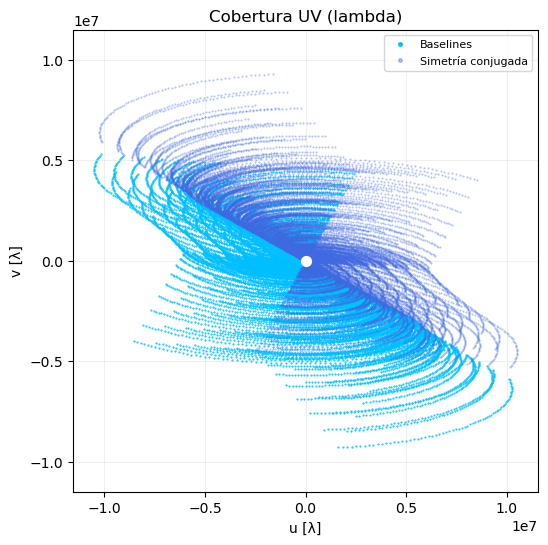

In [3]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "Sirius",
  "utc_start": "2024-10-21T00:00:00",
  "utc_end": "2024-10-21T06:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 100,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V, uvw, uvw_lambda, frequencies, baselines_enu, _ , _ = visibilities_simulation(VLA_L_4)

plot_uv_coverage(uvw, unit='lambda')

## Simulacion VLA Banda L 

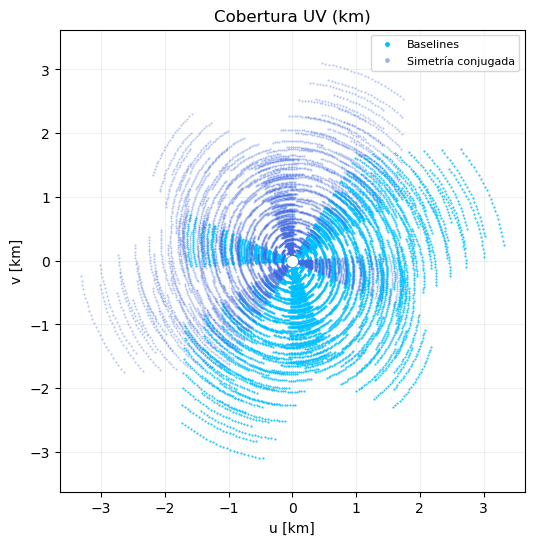

In [4]:
# simulate visibilities no grid
VLA_L_100 = {
  "latitude": -24.0784, # alma coords
  "longitude": -107.6183,
  "file_route": "../antenna_arrays/vla.c.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-09-25T00:00:00",
  "utc_end": "2025-09-25T02:00:00",
  "step_min": 5,
  "n_freqs": 100,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 14,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V , uvw, uvw_lambda, [frequencies, channel_bandwith] , _, sources, dir_cosines = visibilities_simulation(VLA_L_100)

plot_uv_coverage(uvw, unit='km', show_symmetry=True)

## Ejercicio de Programación 2 - Simulación con cobertura UVW real

1. Implementar la ecuación de visibilidad para fuentes puntuales
2. Simular múltiples fuentes con diferentes posiciones y flujos
3. Añadir ruido térmico realista
4. Calcular y visualizar SNR vs distancia UV
5. Analizar la distribución de amplitudes y fases


- 14 Fuentes puntuales

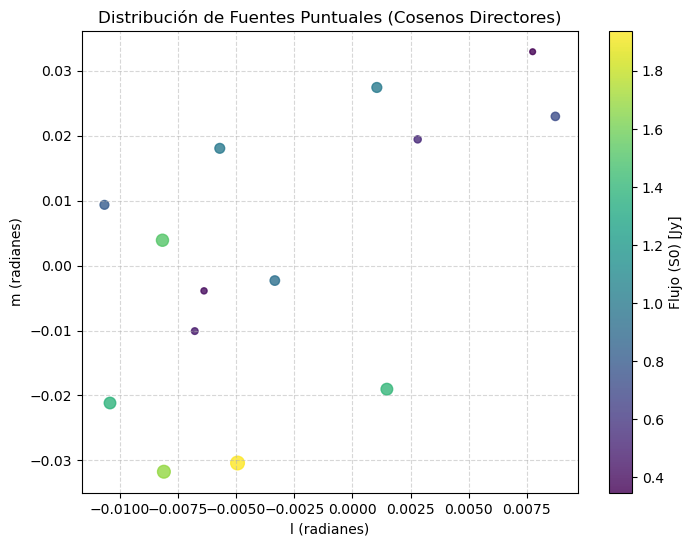

In [5]:
from modules.plots import plot_sources

plot_sources(dir_cosines[0], dir_cosines[1], sources)

Ruido térmico

In [6]:
channel_bandwith

np.float64(10101010.101010084)

In [7]:
from modules.noise import add_thermal_noise

T_sys = 30             # 30 Kelvin
tau = 300              # step_min = 5 -> 300 s

V_noisy, sigma_thermal = add_thermal_noise(V, T_sys, channel_bandwith, tau)

for i, src in enumerate(sources):
    snr = src['S0'] / sigma_thermal 
    print(f"Fuente {i}: Flujo {src['S0']:.2f} Jy -> SNR: {snr:.2f}")

Fuente 0: Flujo 0.39 Jy -> SNR: 0.26
Fuente 1: Flujo 1.40 Jy -> SNR: 0.93
Fuente 2: Flujo 1.52 Jy -> SNR: 1.01
Fuente 3: Flujo 1.94 Jy -> SNR: 1.29
Fuente 4: Flujo 0.72 Jy -> SNR: 0.48
Fuente 5: Flujo 0.80 Jy -> SNR: 0.53
Fuente 6: Flujo 0.99 Jy -> SNR: 0.66
Fuente 7: Flujo 0.46 Jy -> SNR: 0.31
Fuente 8: Flujo 0.35 Jy -> SNR: 0.23
Fuente 9: Flujo 1.00 Jy -> SNR: 0.67
Fuente 10: Flujo 0.53 Jy -> SNR: 0.35
Fuente 11: Flujo 1.37 Jy -> SNR: 0.91
Fuente 12: Flujo 0.93 Jy -> SNR: 0.62
Fuente 13: Flujo 1.68 Jy -> SNR: 1.12


<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10377/1572141299.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Distancia UV ($r_{uv}$) [$\lambda$]')
/tmp/ipykernel_10377/1572141299.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('SNR ($|V_{noisy}| / \sigma_{thermal}$)')


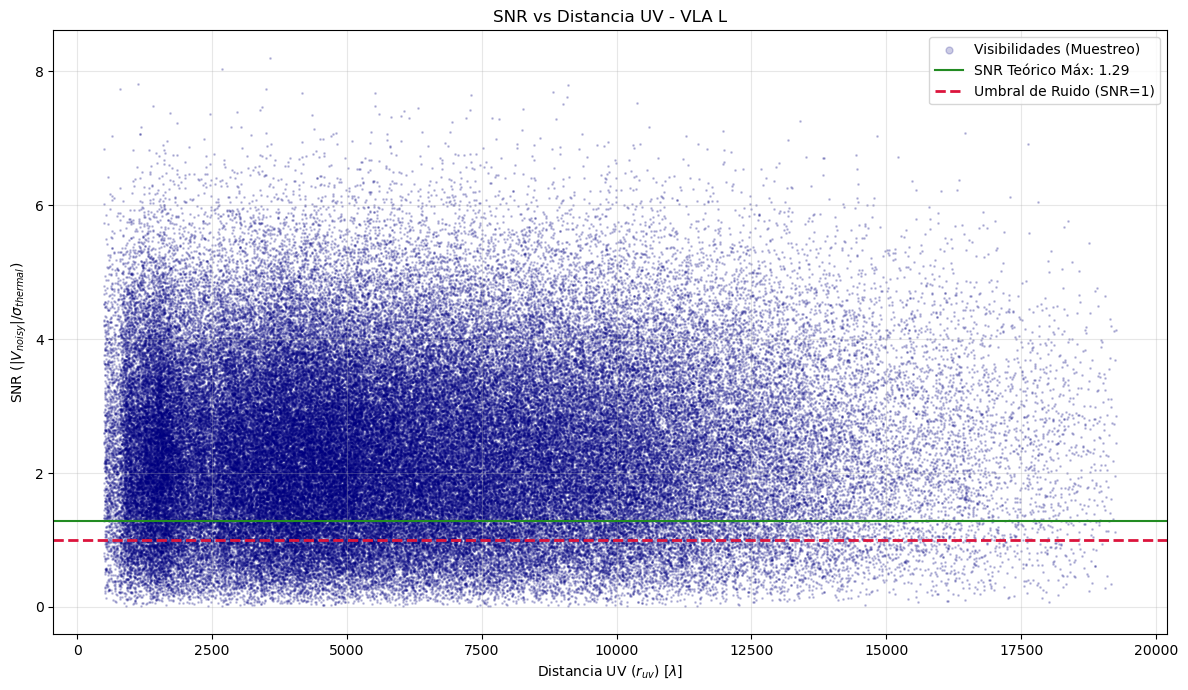

In [8]:
# Extraer coordenadas u, v en unidades de lambda
u_lambda = uvw_lambda[:, :, :, 0]
v_lambda = uvw_lambda[:, :, :, 1]

# Distancia radial UV 
dist_uv_lambda = np.sqrt(u_lambda**2 + v_lambda**2)

# SNR observado (Amplitud / sigma_thermal) 
snr_obs = np.abs(V_noisy) / sigma_thermal

plt.figure(figsize=(12, 7))

# Muestreo: tomamos 1 de cada 5 baselines para visualización
mask = np.random.choice([True, False], size=dist_uv_lambda.shape[0], p=[0.2, 0.8])
x_plot = dist_uv_lambda[mask].flatten()
y_plot = snr_obs[mask].flatten()

plt.scatter(x_plot, y_plot, s=1, alpha=0.2, color='navy', label='Visibilidades (Muestreo)')

# Líneas de referencia teórica 
flujos = [s['S0'] for s in sources]
snr_max_teorico = max(flujos) / sigma_thermal
snr_min_teorico = min(flujos) / sigma_thermal

plt.axhline(y=snr_max_teorico, color='forestgreen', linestyle='-', label=f'SNR Teórico Máx: {snr_max_teorico:.2f}')
plt.axhline(y=1, color='crimson', linestyle='--', linewidth=2, label='Umbral de Ruido (SNR=1)')

plt.title(f'SNR vs Distancia UV - {VLA_L_100["interferometer"]["name"]} {VLA_L_100["interferometer"]["band_name"]}')
plt.xlabel('Distancia UV ($r_{uv}$) [$\lambda$]')
plt.ylabel('SNR ($|V_{noisy}| / \sigma_{thermal}$)')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper right', markerscale=5)
plt.tight_layout()
plt.show()

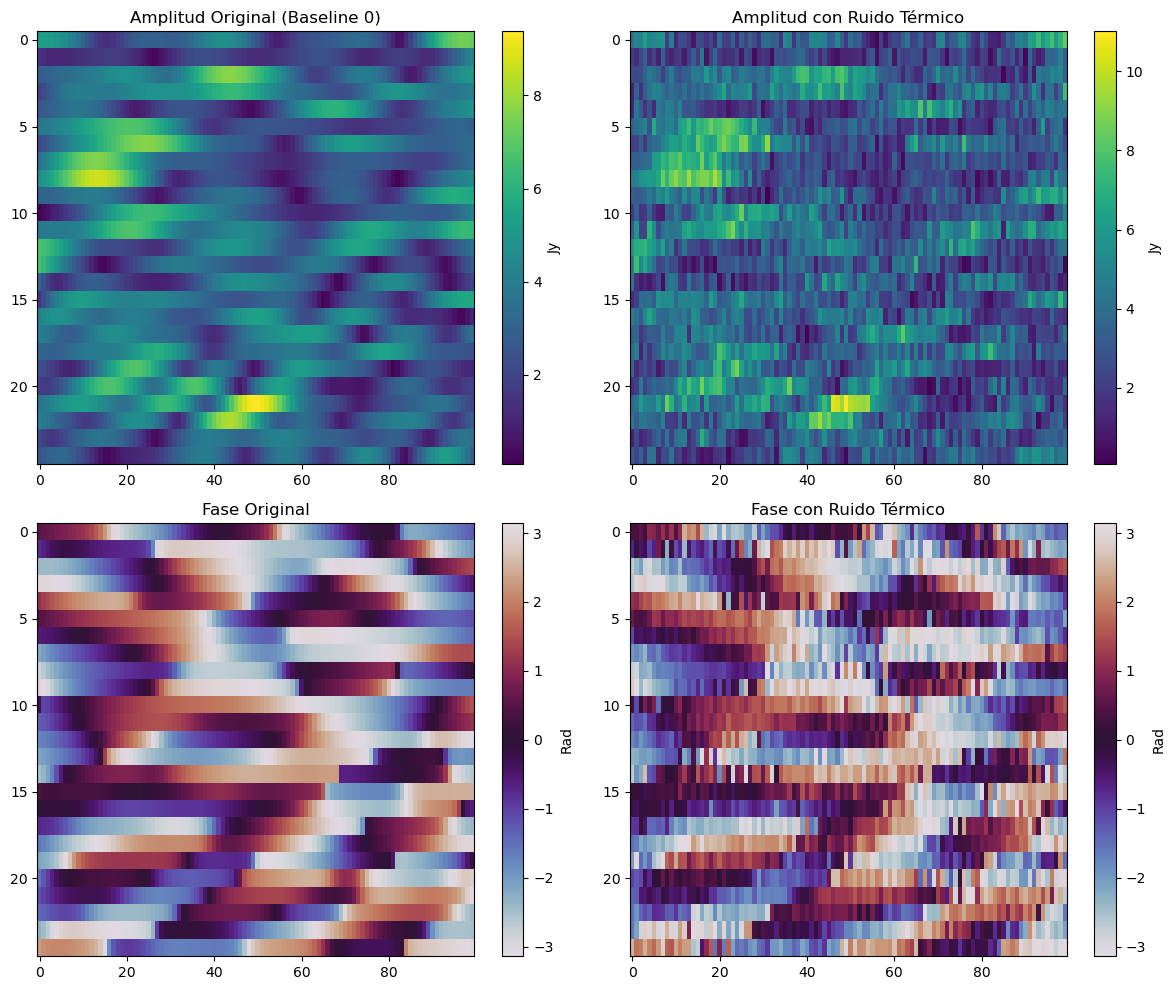

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Amplitudes y fases
amp_true = np.abs(V)
amp_noisy = np.abs(V_noisy)
phase_true = np.angle(V)
phase_noisy = np.angle(V_noisy)

b_idx = 0 
# Reducimos las dimensiones a (25, 100)
img_amp_true = amp_true[b_idx, :, :]
img_amp_noisy = amp_noisy[b_idx, :, :]
img_phase_true = phase_true[b_idx, :, :]
img_phase_noisy = phase_noisy[b_idx, :, :]

# 3. Configuración de la visualización
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
cmap = 'viridis'

# --- Amplitudes ---
im1 = ax[0][0].imshow(img_amp_true, cmap=cmap, aspect='auto')
ax[0][0].set_title(f"Amplitud Original (Baseline {b_idx})")
fig.colorbar(im1, ax=ax[0][0], label='Jy')

im2 = ax[0][1].imshow(img_amp_noisy, cmap=cmap, aspect='auto')
ax[0][1].set_title(f"Amplitud con Ruido Térmico")
fig.colorbar(im2, ax=ax[0][1], label='Jy')

# --- Fases ---
im3 = ax[1][0].imshow(img_phase_true, cmap='twilight', aspect='auto', vmin=-np.pi, vmax=np.pi)
ax[1][0].set_title("Fase Original")
fig.colorbar(im3, ax=ax[1][0], label='Rad')

im4 = ax[1][1].imshow(img_phase_noisy, cmap='twilight', aspect='auto', vmin=-np.pi, vmax=np.pi)
ax[1][1].set_title("Fase con Ruido Térmico")
fig.colorbar(im4, ax=ax[1][1], label='Rad')

plt.tight_layout()
plt.show()